# Workflow Prototype

How can we go from an image to a plan for our drone? How can we collect valuable metrics about our workflow?


**Gameplan:**
- Image Pre-processing:
    - Can we find techniques and default values suitable for this environment?
- Find regions
    - Bounding boxes (if necessary)
    - Region areas
    - Centroid points
- Post-Processing Analysis
    - Filtering by region sizes
    - Number of estimated pellets needed
    - Connect centroids with TSP


In [44]:
# Load required libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from skimage.filters import threshold_otsu
from skimage.color import rgb2lab
from scipy.ndimage import gaussian_filter, label
import rasterio
from rasterio.plot import show
from PIL import Image
from ipywidgets import interact, FloatSlider
import os
import sys
from pathlib import Path

# Add the parent directory to the Python path
# So we can find local modules e.g. "plant_search"
sys.path.append(str(Path.cwd().parent))

%matplotlib inline

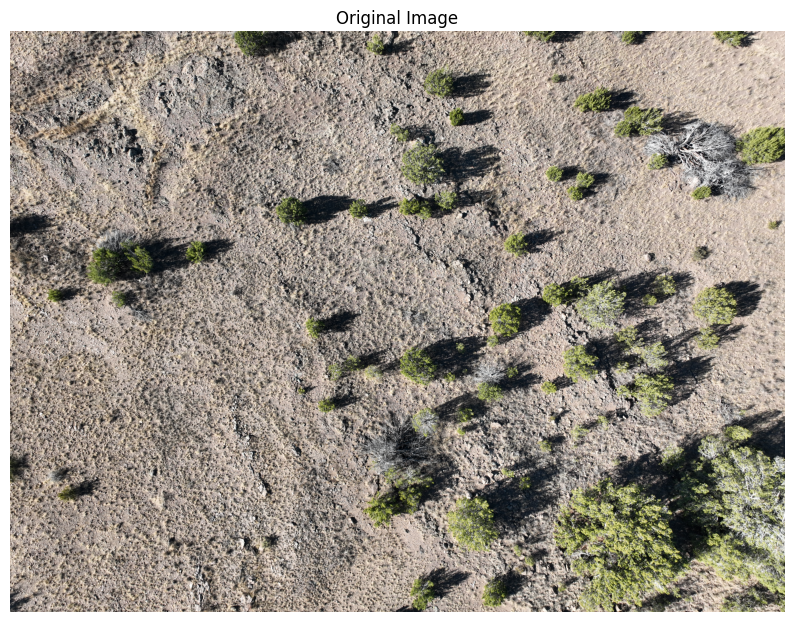

In [45]:
from plant_search.load_image import load_image, plot_image


# file_path = 'input/ESPG-4326-orthophoto.tif'
# file_path = 'input/MADRID_RGB.tif'
# file_path = '../input/aerial-trees.jpg'

# file_path = '../input/DJI_0010.JPG'
# file_path = '../input/DJI_0015.JPG'
file_path = '../input/DJI_0093.JPG'
# file_path = '../input/DJI_0119.JPG'
# file_path = '../input/Brewster-ortho.tif'

ds = 4 # downscale ratio

image = load_image(file_path)
if image is not None:
    plot_image(image, "Original Image")
    image = image[::ds, ::ds]


## Image Pre-Processing

- Vegetation Index (ExG)
- Bilateral Filtering

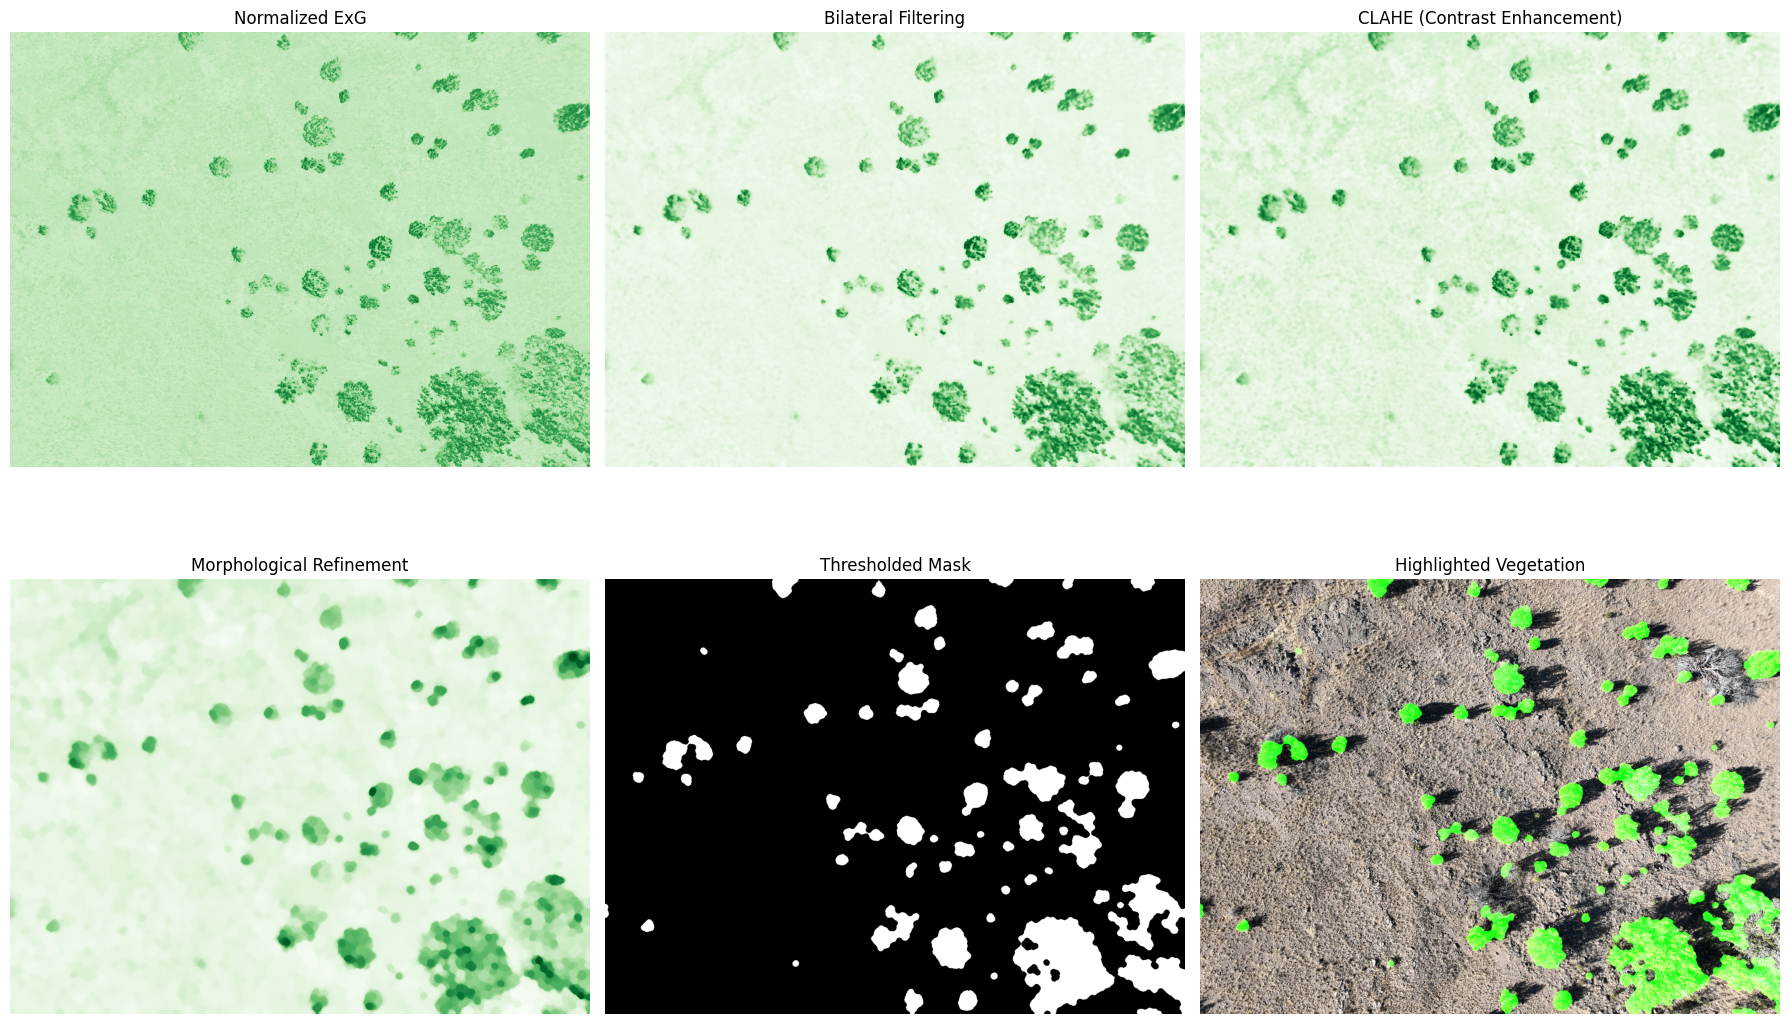

In [46]:
from plant_search.vegetation_indices import calculate_exg, normalize_rgb
from skimage.exposure import equalize_adapthist
from skimage.morphology import opening, closing, disk


# Normalize ExG to the range [0, 255] for OpenCV compatibility
exg = calculate_exg(*normalize_rgb(image))
exg_normalized = (exg - np.min(exg)) / (np.max(exg) - np.min(exg))  # Normalize to [0, 1]
exg_uint8 = (exg_normalized * 255).astype(np.uint8)


# Step 1: Bilateral Filtering using OpenCV
bl_sigma_color = 50
bl_sigma_spatial = 15 # Lower number is faster

bilateral_smoothed_exg = cv2.bilateralFilter(
    exg_uint8 , d=9, 
    sigmaColor=bl_sigma_color, 
    sigmaSpace=bl_sigma_spatial
)
bilateral_smoothed_exg = bilateral_smoothed_exg / 255.0  # Scale back to [0, 1]

# Step 2: Contrast Enhancement with CLAHE
clahe_exg = equalize_adapthist(bilateral_smoothed_exg, clip_limit=0.008)

# Step 3: Morphological Operations (Opening → Closing)
selem = disk(7)  # Structuring element
morph_exg = closing(opening(clahe_exg, selem), selem)

# Step 4: Thresholding (Otsu's method)
otsu_threshold = threshold_otsu(morph_exg)
binary_mask = morph_exg > otsu_threshold

highlighted_image = image.copy() * 255
# Enhance the mask regions with green (or any desired enhancement)
highlighted_image[binary_mask, 1] = 1.0  # Max out the green channel for mask regions


# Visualize the Pipeline
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes[0, 0].imshow(exg_normalized, cmap='Greens')
axes[0, 0].set_title("Normalized ExG")
axes[0, 0].axis("off")

axes[0, 1].imshow(bilateral_smoothed_exg, cmap='Greens')
axes[0, 1].set_title("Bilateral Filtering")
axes[0, 1].axis("off")

axes[0, 2].imshow(clahe_exg, cmap='Greens')
axes[0, 2].set_title("CLAHE (Contrast Enhancement)")
axes[0, 2].axis("off")

axes[1, 0].imshow(morph_exg, cmap='Greens')
axes[1, 0].set_title("Morphological Refinement")
axes[1, 0].axis("off")

axes[1, 1].imshow(binary_mask, cmap='gray')
axes[1, 1].set_title("Thresholded Mask")
axes[1, 1].axis("off")

# axes[1, 2].imshow(np.clip(highlighted, 0, 1))
axes[1, 2].imshow(highlighted_image * 255)
axes[1, 2].set_title("Highlighted Vegetation")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

## Region Search
- Bounding boxes (if necessary)
- Region areas
- Centroid points

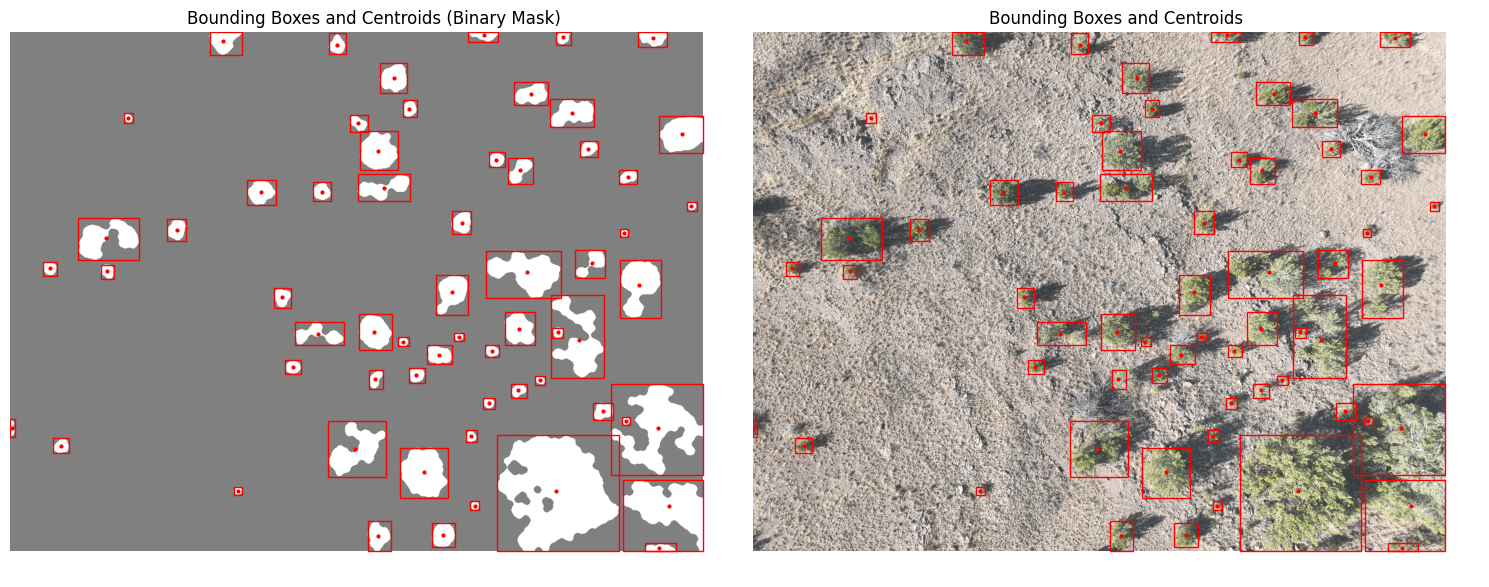

Number of regions (detected plants): 62
Number of centroids (detected plants): 62


In [47]:

from skimage.measure import label, regionprops
from skimage.morphology import closing, disk

# Step 1: Preprocess the binary mask
selem = disk(3)  # Structuring element
cleaned_mask = closing(binary_mask, selem)  # Fill small gaps

# Step 2: Label connected components
labeled_mask = label(cleaned_mask)
regions = regionprops(labeled_mask)

# Step 3: Extract centroids and bounding boxes
centroids = []
bounding_boxes = []

for region in regions:
    # Centroid
    centroid = region.centroid  # (row, col)
    centroids.append((round(centroid[1], 2), round(centroid[0], 2)))  # Format x, y to 2 decimal places

    # Bounding box
    min_row, min_col, max_row, max_col = region.bbox
    bounding_boxes.append(((min_col, min_row), (max_col, max_row)))



fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax1, ax2 = axes[0], axes[1]

# Step 4: Visualize results on binary mask
ax1.imshow(cleaned_mask, cmap="gray", alpha=0.5)
ax1.set_title("Bounding Boxes and Centroids (Binary Mask)")
ax1.axis("off")
for bbox, centroid in zip(bounding_boxes, centroids):
    (min_col, min_row), (max_col, max_row) = bbox # Draw bounding box
    ax1.add_patch(plt.Rectangle((min_col, min_row), max_col - min_col, max_row - min_row,
                                edgecolor="red", fill=False, linewidth=1))
    ax1.plot(centroid[0], centroid[1], "ro", markersize=2)  # Plot centroid

# Step 5: Visualize results on original image
ax2.imshow(image, alpha=0.8)
ax2.set_title("Bounding Boxes and Centroids")
ax2.axis("off")
for bbox, centroid in zip(bounding_boxes, centroids):
    (min_col, min_row), (max_col, max_row) = bbox # Draw bounding box
    ax2.add_patch(plt.Rectangle((min_col, min_row), max_col - min_col, max_row - min_row,
                                edgecolor="red", fill=False, linewidth=1))
    ax2.plot(centroid[0], centroid[1], "ro", markersize=2)  # Plot centroid

plt.tight_layout()
plt.show()


print(f"Number of regions (detected plants): {len(regions)}")
print(f"Number of centroids (detected plants): {len(centroids)}")

# Output centroids
# print("Detected Centroids:")
# for idx, centroid in enumerate(centroids):
#     print(f"Plant {idx + 1}: Centroid at (x={centroid[0]:.2f}, y={centroid[1]:.2f})")


## Post-Processing Analysis
- Filtering by region sizes
- Number of estimated pellets needed
- Connect centroids with TSP

In [48]:
# Guestimating size of visible area 
import math

def calculate_ground_coverage_and_resolution(altitude, fov_horizontal, image_width, image_height):
    """
    Calculate the ground coverage and pixel resolution of an image.

    Parameters:
        altitude (float): Altitude of the drone in meters.
        fov_horizontal (float): Horizontal field of view of the camera in degrees.
        fov_vertical (float): Vertical field of view of the camera in degrees.
        image_width (int): Width of the image in pixels.
        image_height (int): Height of the image in pixels.

    Returns:
        dict: A dictionary containing ground width, ground height, pixel width, and pixel height.
    """
    # Convert FoV from degrees to radians
    fov_horizontal_rad = math.radians(fov_horizontal)

    # Calculate ground coverage
    ground_width = 2 * altitude * math.tan(fov_horizontal_rad / 2)  # in meters
    ground_height = ground_width * (image_height / image_width)  # in meters

    # Calculate pixel resolution
    pixel_width = ground_width / image_width  # meters per pixel
    pixel_height = ground_height / image_height  # meters per pixel

    return {
        "ground_width": ground_width,
        "ground_height": ground_height,
        "pixel_width": pixel_width,
        "pixel_height": pixel_height,
    }


In [49]:
# Cheap way to estimate if we know altitude and FOV
cam_horiz_fov = 84 # degrees
photo_alt = 35 # meters
im_height, im_width = image.shape[:2] # assuming ndarray

result = calculate_ground_coverage_and_resolution(
    photo_alt, cam_horiz_fov, im_width, im_height
)

print("Ground Coverage and Pixel Resolution:")
print(f"Ground Width: {result['ground_width']} meters")
print(f"Ground Height: {result['ground_height']} meters")
print(f"Pixel Width: {result['pixel_width']} meters per pixel")
print(f"Pixel Height: {result['pixel_height']} meters per pixel")

Ground Coverage and Pixel Resolution:
Ground Width: 63.028283100848796 meters
Ground Height: 47.22346362631777 meters
Pixel Width: 0.04774869931882485 meters per pixel
Pixel Height: 0.04774869931882485 meters per pixel


In [50]:
# Size and categorize detected regions
def calculate_region_area(region_mask, pixel_width, pixel_height):
    """
    Calculate the area of a region in real-world units.

    Parameters:
        region_mask (np.ndarray): A binary mask where the region is 1 and background is 0.
        pixel_width (float): Real-world width of a pixel (in meters).
        pixel_height (float): Real-world height of a pixel (in meters).

    Returns:
        float: The area of the region in square meters.
    """
    # Count the number of pixels in the region
    pixel_count = np.sum(region_mask)
    
    # Calculate the area in real-world units
    pixel_area = pixel_width * pixel_height  # Area of one pixel
    region_area = pixel_count * pixel_area  # Total area of the region
    
    return region_area


def color_regions_by_area(image, region_masks, pixel_width, pixel_height, thresholds):
    """
    Color regions based on their area in the original image.

    Parameters:
        image (np.ndarray): Original image array (e.g., RGB).
        region_masks (list of np.ndarray): List of binary masks for each region.
        pixel_width (float): Real-world width of a pixel (in meters).
        pixel_height (float): Real-world height of a pixel (in meters).
        thresholds (dict): Dictionary defining area thresholds in square meters.
                           Example: {"small": 10, "medium": 50, "large": float('inf')}

    Returns:
        np.ndarray: Image with regions colored based on area.
    """
    # Create a copy of the original image to modify
    colored_image = image.copy()

    # Define colors for each category
    colors = {
        "small": [255, 0, 0],   # Red
        "medium": [0, 255, 0],  # Green
        "large": [0, 0, 255],   # Blue
    }

    # Iterate through each region mask
    for region_mask in region_masks:
        # Calculate the area of the region
        region_area = calculate_region_area(region_mask, pixel_width, pixel_height)
        
        # Determine the category of the region
        if region_area <= thresholds["small"]:
            category = "small"
        elif thresholds["small"] < region_area <= thresholds["medium"]:
            category = "medium"
        else:
            category = "large"
        
        # Color the region based on its category
        for channel in range(colored_image.shape[2]):  # Loop through RGB channels
            colored_image[:, :, channel] = np.where(
                region_mask == 1,
                colors[category][channel],
                colored_image[:, :, channel]
            )
    
    return colored_image





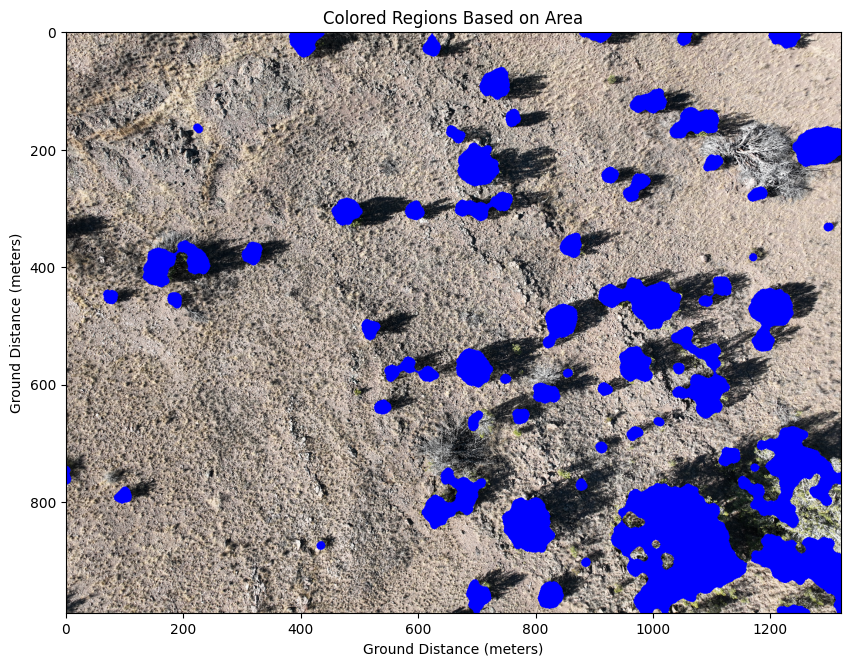

In [65]:
import numpy as np

# Example inputs
region_masks = [
    cleaned_mask
]
pixel_width = result['pixel_width']  # meters per pixel
pixel_height = result['pixel_height'] # meters per pixel
thresholds = {"small": 10, "medium": 50, "large": float('inf')}  # Area thresholds in square meters

# Color regions
colored_image = color_regions_by_area(image, region_masks, pixel_width, pixel_height, thresholds)

# Set up figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate extent in meters
extent = [
    0,  # Start of x-axis (0 meters)
    colored_image.shape[1] * pixel_width,  # End of x-axis (meters)
    0,  # Start of y-axis (0 meters)
    colored_image.shape[0] * pixel_height,  # End of y-axis (meters)
]

# Display the image
ax.imshow(colored_image, extent=extent)
ax.set_xlabel("Ground Distance (meters)")
ax.set_ylabel("Ground Distance (meters)")
ax.set_title("Colored Regions Based on Area")

plt.imshow(colored_image)
plt.show()


In [68]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

def color_regions_by_area_colormap(image, region_mask, pixel_width, pixel_height, colormap_name="viridis"):
    """
    Color regions based on their area using a colormap.

    Parameters:
        image (np.ndarray): Original image array (e.g., RGB).
        region_mask (np.ndarray): Binary mask for region.
        pixel_width (float): Real-world width of a pixel (in meters).
        pixel_height (float): Real-world height of a pixel (in meters).
        colormap_name (str): Name of the matplotlib colormap to use.

    Returns:
        tuple: A tuple containing the colored image (np.ndarray) and the normalized areas.
    """
    # Calculate the area for each region
    # areas = [
    #     calculate_region_area(region_mask, pixel_width, pixel_height)
    #     for region_mask in region_masks
    # ]

    areas = calculate_region_area(region_mask, pixel_width, pixel_height)

    # Normalize areas to the range [0, 1] for colormap mapping
    norm = mcolors.Normalize(vmin=min(areas), vmax=max(areas))
    colormap = plt.get_cmap(colormap_name)

    # Create an empty RGB image for the output
    # colored_image = np.zeros_like(image, dtype=np.float32)
    colored_image = image

    # Color each region based on the normalized area
    for area in areas:
        color = colormap(norm(area))  # Get RGBA color from colormap
        for channel in range(3):  # Apply color to the RGB channels
            colored_image[:, :, channel] = np.where(
                region_mask == 1,
                color[channel],  # Use the colormap's color for the region
                colored_image[:, :, channel]
            )

    return (colored_image, areas)

def plot_colored_regions_with_colormap(colored_image, areas, pixel_width, pixel_height, colormap_name="viridis"):
    """
    Plot the colored regions with axes representing ground distance in meters and a colormap legend.

    Parameters:
        colored_image (np.ndarray): Image with regions colored based on area.
        areas (list of float): List of region areas in square meters.
        pixel_width (float): Real-world width of a pixel (in meters).
        pixel_height (float): Real-world height of a pixel (in meters).
        colormap_name (str): Name of the matplotlib colormap used.
    """
    # Set up figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))

    # Calculate extent in meters
    extent = [
        0,  # Start of x-axis (0 meters)
        colored_image.shape[1] * pixel_width,  # End of x-axis (meters)
        0,  # Start of y-axis (0 meters)
        colored_image.shape[0] * pixel_height,  # End of y-axis (meters)
    ]

    # Display the image
    ax.imshow(colored_image, extent=extent)
    ax.set_xlabel("Ground Distance (meters)")
    ax.set_ylabel("Ground Distance (meters)")
    ax.set_title("Colored Regions Based on Area (Colormap)")

    # Add a colorbar
    sm = plt.cm.ScalarMappable(cmap=colormap_name, norm=mcolors.Normalize(vmin=min(areas), vmax=max(areas)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Region Area (m²)")

    plt.show()


In [71]:
region_mask = cleaned_mask

# Color regions using a colormap
colored_image, areas = color_regions_by_area_colormap(image, region_mask, pixel_width, pixel_height, colormap_name="viridis")

# Plot the colored regions with axes and a colormap legend
plot_colored_regions_with_colormap(colored_image, areas, pixel_width, pixel_height, colormap_name="viridis")



TypeError: 'numpy.float64' object is not iterable

In [60]:
# Number of estimated pellets needed